In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# VOICE SPECTROGRAM TRAINING (CNN)
# CORRECTED: SUBJECT-LEVEL SPLIT + BASELINES
# ============================================================

import os
import random
import re
from collections import defaultdict

import numpy as np
import librosa
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# -----------------------------
# 0. Repro & Performance
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# -----------------------------
# 1. Paths & File Collection
# -----------------------------
base_dir = r"/content/drive/MyDrive/EWA-DB_AD_PD_voice"
classes = ["Alzheimer", "Parkinson", "Healthy1"]
num_classes = len(classes)

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints_ewa_stft"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LAST_CKPT = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
BEST_CKPT = os.path.join(CHECKPOINT_DIR, "best_checkpoint.pth")

# Collect all WAV paths
wav_paths = {cls: [] for cls in classes}

for cls in classes:
    input_path = os.path.join(base_dir, cls)
    for root, dirs, files in os.walk(input_path):
        for file in files:
            if file.lower().endswith(".wav"):
                wav_paths[cls].append(os.path.join(root, file))

print("✅ Path collection complete:")
for cls in classes:
    print(f"{cls}: {len(wav_paths[cls])} files")

# -----------------------------
# 2. STRICT SUBJECT-LEVEL SPLIT
# -----------------------------
all_files = []
all_labels = []
all_subjects = []

for cls_idx, cls in enumerate(classes):
    for path in wav_paths[cls]:
        all_files.append(path)
        all_labels.append(cls_idx)

        # Extract subject ID safely (assumes prefix before _ or - is subject ID)
        basename = os.path.basename(path)
        subj_id = re.split(r'[_\\-]', basename)[0]
        # Make subject ID unique across classes just in case
        all_subjects.append(f"{cls}_{subj_id}")

all_files = np.array(all_files)
all_labels = np.array(all_labels)
all_subjects = np.array(all_subjects)

# Step A: Hold out 15% of SUBJECTS for the unseen Test Set
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(all_files, all_labels, groups=all_subjects))

temp_files = all_files[train_val_idx]
temp_labels = all_labels[train_val_idx]
temp_subjects = all_subjects[train_val_idx]

test_files = all_files[test_idx].tolist()
test_labels = all_labels[test_idx].tolist()

# Step B: Split the remaining subjects into Train and Val (~17.6% gives 15% overall)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
train_idx, val_idx = next(gss_val.split(temp_files, temp_labels, groups=temp_subjects))

train_files = temp_files[train_idx].tolist()
train_labels = temp_labels[train_idx].tolist()
val_files = temp_files[val_idx].tolist()
val_labels = temp_labels[val_idx].tolist()

# 🔥 PROOF FOR EXAMINER: Prove no patient exists in both Train and Test
train_subs = set(temp_subjects[train_idx])
test_subs = set(all_subjects[test_idx])
print(f"Leakage Proof (Shared Subjects between Train & Test): {len(train_subs & test_subs)}")

print("✅ Subject-Level Split complete")
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

# -----------------------------
# 3. Oversample minority classes (Train Only)
# -----------------------------
counts = defaultdict(list)
for f, l in zip(train_files, train_labels):
    counts[l].append(f)

max_count = max(len(v) for v in counts.values())
oversampled_files, oversampled_labels = [], []

for label, files in counts.items():
    n_repeat = max_count // len(files)
    remainder = max_count % len(files)

    balanced_files = files * n_repeat + files[:remainder]
    oversampled_files.extend(balanced_files)
    oversampled_labels.extend([label] * len(balanced_files))

combined = list(zip(oversampled_files, oversampled_labels))
random.shuffle(combined)
oversampled_files, oversampled_labels = zip(*combined)

oversampled_files = list(oversampled_files)
oversampled_labels = list(oversampled_labels)

print(f"✅ Oversampled train set: {len(oversampled_files)} files")

# -----------------------------
# 4. Audio Augmentation & Spectrogram
# -----------------------------
def add_noise(y, noise_factor=0.005):
    return y + noise_factor * np.random.randn(len(y))

def pitch_shift(y, sr, n_steps):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def time_stretch(y, rate):
    return librosa.effects.time_stretch(y=y, rate=rate)

def wav_to_spectrogram(path, img_size=224, augment=False, sr=16000):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)

        if augment:
            aug = np.random.choice(["noise", "pitch", "stretch", "none"])
            if aug == "noise":
                y = add_noise(y)
            elif aug == "pitch":
                y = pitch_shift(y, sr, np.random.uniform(-2, 2))
            elif aug == "stretch":
                y = time_stretch(y, np.random.uniform(0.9, 1.1))

        D = librosa.stft(y, n_fft=2048, hop_length=512)
        S, _ = librosa.magphase(D)
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        S_db_norm = cv2.normalize(S_db, None, 0, 255, cv2.NORM_MINMAX)
        img = cv2.resize(S_db_norm, (img_size, img_size))
        img = np.stack([img, img, img], axis=0)
        img = img / 255.0
        return img.astype("float32")

    except Exception as e:
        print(f"⚠️ Error loading {path}: {e}")
        return np.zeros((3, img_size, img_size), dtype="float32")

# -----------------------------
# 5. Dataset & DataLoaders
# -----------------------------
class AudioDataset(Dataset):
    def __init__(self, files, labels, augment_classes=None):
        self.files = files
        self.labels = labels
        self.augment_classes = augment_classes if augment_classes is not None else [0, 1]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        label = self.labels[idx]
        augment = label in self.augment_classes
        X = wav_to_spectrogram(self.files[idx], augment=augment)
        return torch.tensor(X, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

BATCH_SIZE = 32

train_ds = AudioDataset(oversampled_files, oversampled_labels, augment_classes=[0, 1])
val_ds   = AudioDataset(val_files, val_labels, augment_classes=[])
test_ds  = AudioDataset(test_files, test_labels, augment_classes=[])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# -----------------------------
# 6. CNN Model
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))   # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))   # 56 -> 28
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

model = CNNClassifier(num_classes=num_classes).to(device)

# -----------------------------
# 7. Checkpoint & Metric Helpers
# -----------------------------
def save_checkpoint(path, epoch, model, optimizer, best_val_score):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_score": best_val_score
    }, path)

def load_checkpoint(path, model, optimizer, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    resumed_epoch = ckpt["epoch"] + 1
    best_val_score = ckpt.get("best_val_score", 0.0)
    print(f"✅ Resumed from epoch {resumed_epoch}")
    return resumed_epoch, best_val_score

def safe_multiclass_roc_auc(y_true, y_prob):
    try:
        return roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
    except ValueError:
        return float("nan")

def compute_metrics(y_true, y_pred, y_prob, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=list(range(len(class_names)))
    )
    roc_auc = safe_multiclass_roc_auc(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    return {
        "acc": acc, "precision_weighted": precision_w, "recall_weighted": recall_w, "f1_weighted": f1_w,
        "precision_macro": precision_m, "recall_macro": recall_m, "f1_macro": f1_m, "roc_auc": roc_auc, "cm": cm,
        "per_class_precision": per_class_precision, "per_class_recall": per_class_recall, "per_class_f1": per_class_f1, "per_class_support": per_class_support
    }

def evaluate_model(model, loader, criterion, device, class_names):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * X.size(0)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs, class_names)
    metrics["loss"] = avg_loss
    metrics["labels"] = all_labels
    metrics["preds"] = all_preds
    metrics["probs"] = all_probs
    return metrics

def print_epoch_summary(epoch, total_epochs, train_metrics, val_metrics, class_names):
    print(f"\n{'=' * 90}\nEpoch {epoch + 1}/{total_epochs}\n{'=' * 90}")
    print(f"Train | Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1(w): {train_metrics['f1_weighted']:.4f}")
    print(f"Val   | Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1(w): {val_metrics['f1_weighted']:.4f}")

# -----------------------------
# 8. Training Setup & Loop
# -----------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
EPOCHS = 20

start_epoch = 0
best_val_score = 0.0

if os.path.exists(LAST_CKPT):
    start_epoch, best_val_score = load_checkpoint(LAST_CKPT, model, optimizer, device)

history = []

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    all_train_labels, all_train_preds, all_train_probs = [], [], []

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * X.size(0)
        all_train_labels.extend(y.detach().cpu().numpy())
        all_train_preds.extend(preds.detach().cpu().numpy())
        all_train_probs.extend(probs.detach().cpu().numpy())

    all_train_labels = np.array(all_train_labels)
    all_train_preds = np.array(all_train_preds)
    all_train_probs = np.array(all_train_probs)

    train_metrics = compute_metrics(all_train_labels, all_train_preds, all_train_probs, classes)
    train_metrics["loss"] = running_loss / len(train_loader.dataset)

    val_metrics = evaluate_model(model, val_loader, criterion, device, classes)
    print_epoch_summary(epoch, EPOCHS, train_metrics, val_metrics, classes)

    save_checkpoint(LAST_CKPT, epoch, model, optimizer, best_val_score)

    if val_metrics["acc"] > best_val_score:
        best_val_score = val_metrics["acc"]
        save_checkpoint(BEST_CKPT, epoch, model, optimizer, best_val_score)
        print("⭐ Best model saved based on Val Accuracy")

# -----------------------------
# 9. Final Test Evaluation
# -----------------------------
if os.path.exists(BEST_CKPT):
    ckpt = torch.load(BEST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print("\n✅ Best checkpoint loaded for final evaluation")

test_metrics = evaluate_model(model, test_loader, criterion, device, classes)

print(f"\n{'=' * 90}")
print("✅ Final Test Results (Unseen Holdout Set)")
print(f"{'=' * 90}")
print(f"Acc: {test_metrics['acc']:.4f} | F1(w): {test_metrics['f1_weighted']:.4f} | ROC-AUC: {test_metrics['roc_auc']:.4f}")

# -----------------------------
# 10. BASELINE COMPARISON (The Reviewer's Request)
# -----------------------------
from sklearn.ensemble import RandomForestClassifier

print("\n--- VOICE SPECTROGRAM BASELINE COMPARISON ---")

# Helper to extract a subset of flat features to prevent RAM crash
def extract_flat_features(loader, max_samples=2000):
    X_flat, y_list = [], []
    count = 0
    for X_b, y_b in loader:
        X_flat.append(X_b.view(X_b.size(0), -1).numpy())
        y_list.append(y_b.numpy())
        count += X_b.size(0)
        if count >= max_samples:
            break
    return np.concatenate(X_flat)[:max_samples], np.concatenate(y_list)[:max_samples]

print("Extracting features for baseline Random Forest...")
X_train_flat, y_train_base = extract_flat_features(train_loader, max_samples=2000)
X_test_flat, y_test_base = extract_flat_features(test_loader, max_samples=2000)

rf = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rf.fit(X_train_flat, y_train_base)
rf_preds = rf.predict(X_test_flat)

print(f"Baseline Random Forest -> Acc: {accuracy_score(y_test_base, rf_preds):.4f} | F1: {f1_score(y_test_base, rf_preds, average='weighted'):.4f}")
print(f"Proposed CNN Model     -> Acc: {test_metrics['acc']:.4f} | F1: {test_metrics['f1_weighted']:.4f}")

# -----------------------------
# 11. Export for Flutter
# -----------------------------
from torch.utils.mobile_optimizer import optimize_for_mobile

EXPORT_DIR = "/content/drive/MyDrive"
PT_PATH = os.path.join(EXPORT_DIR, "finalADPDVoice.pt")
PTL_PATH = os.path.join(EXPORT_DIR, "finalADPDVoice.ptl")

model.eval()
model.cpu()

example_input = torch.randn(1, 3, 224, 224)
traced_model = torch.jit.trace(model, example_input)
traced_model.save(PT_PATH)

optimized_lite_model = optimize_for_mobile(traced_model)
optimized_lite_model._save_for_lite_interpreter(PTL_PATH)

print(f"\n✅ Export Complete! Saved .ptl model to: {PTL_PATH}")

✅ Path collection complete:
Alzheimer: 2763 files
Parkinson: 6516 files
Healthy1: 11260 files
Leakage Proof (Shared Subjects between Train & Test): 0
✅ Subject-Level Split complete
Train: 14553 | Val: 2529 | Test: 3457
✅ Oversampled train set: 24999 files
✅ Using device: cpu
✅ Resumed from epoch 20

✅ Best checkpoint loaded for final evaluation

✅ Final Test Results (Unseen Holdout Set)
Acc: 0.9534 | F1(w): 0.9551 | ROC-AUC: 0.9956

--- VOICE SPECTROGRAM BASELINE COMPARISON ---
Extracting features for baseline Random Forest...
Baseline Random Forest -> Acc: 0.7270 | F1: 0.7370
Proposed CNN Model     -> Acc: 0.9534 | F1: 0.9551

✅ Export Complete! Saved .ptl model to: /content/drive/MyDrive/finalADPDVoice.ptl


/tmp/ipykernel_5733/3197876392.py:435: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_lite_model._save_for_lite_interpreter(PTL_PATH)


In [ ]:
# -----------------------------
# Export best model as .pt and .ptl
# -----------------------------
import os
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile

EXPORT_DIR = "/content/drive/MyDrive"
PT_PATH = os.path.join(EXPORT_DIR, "finalADPDVoice.pt")
PTL_PATH = os.path.join(EXPORT_DIR, "finalADPDVoice.ptl")

# Load best checkpoint weights again to be safe
if os.path.exists(BEST_CKPT):
    ckpt = torch.load(BEST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print("✅ Best checkpoint loaded for export")
else:
    print("⚠️ Best checkpoint not found, exporting current model weights")

model.eval()
model.cpu()

# Example input for tracing
example_input = torch.randn(1, 3, 224, 224)

# Convert to TorchScript
traced_model = torch.jit.trace(model, example_input)
traced_model.save(PT_PATH)

# Convert to Lite Interpreter format (.ptl)
optimized_lite_model = optimize_for_mobile(traced_model)
optimized_lite_model._save_for_lite_interpreter(PTL_PATH)

print(f"✅ Saved .pt model to: {PT_PATH}")
print(f"✅ Saved .ptl model to: {PTL_PATH}")

✅ Best checkpoint loaded for export
✅ Saved .pt model to: /content/drive/MyDrive/finalADPDVoice.pt
✅ Saved .ptl model to: /content/drive/MyDrive/finalADPDVoice.ptl


/tmp/ipykernel_5733/1252612857.py:32: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_lite_model._save_for_lite_interpreter(PTL_PATH)


In [ ]:
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile

# Assuming 'model' is your CNNClassifier already loaded with best_checkpoint.pth
model.eval()

print("Exporting pure, un-wrapped model...")

# Trace the pure model directly! No wrappers, no baked-in Softmax.
example_input = torch.randn(1, 3, 224, 224).to(device)
traced_model = torch.jit.trace(model, example_input)
optimized_lite_model = optimize_for_mobile(traced_model)

save_path = "/content/drive/MyDrive/voice_pure.ptl"
optimized_lite_model._save_for_lite_interpreter(save_path)

print(f" Success! Download: {save_path}")

Exporting pure, un-wrapped model...
 Success! Download: /content/drive/MyDrive/voice_pure.ptl


/tmp/ipykernel_5733/1511435715.py:15: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_lite_model._save_for_lite_interpreter(save_path)



--- VOICE CALIBRATION ANALYSIS ---
Brier Score (Voice): 0.0242


<Figure size 800x600 with 0 Axes>

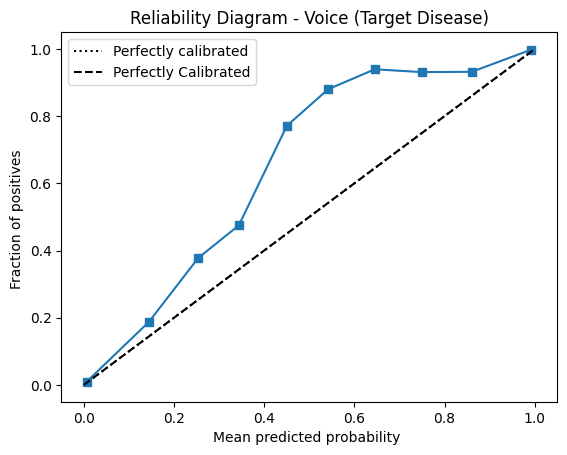

In [ ]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

print("\n--- VOICE CALIBRATION ANALYSIS ---")
TARGET_CLASS = 1 # Change to match your PD or AD label index
class_name = "Target Disease"

voice_probs = []
voice_labels = []

model.eval()
with torch.no_grad():
    for spectrograms, labels in test_loader:
        out = model(spectrograms.to(device))
        # Extract the specific probability for the target class
        probs = F.softmax(out, dim=1)[:, TARGET_CLASS]
        voice_probs.extend(probs.cpu().numpy())
        voice_labels.extend(labels.numpy())

# Binarize labels
binary_labels = (np.array(voice_labels) == TARGET_CLASS).astype(int)

brier = brier_score_loss(binary_labels, voice_probs)
print(f"Brier Score (Voice): {brier:.4f}")

prob_true, prob_pred = calibration_curve(binary_labels, voice_probs, n_bins=10)
disp = CalibrationDisplay(prob_true, prob_pred, binary_labels)

plt.figure(figsize=(8, 6))
disp.plot()
plt.title(f"Reliability Diagram - Voice ({class_name})")
plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
plt.legend()
plt.savefig("calibration_voice.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import torch
import torchvision.transforms as T
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

print("\n=======================================================")
print(" 1. VOICE: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)")
print("=======================================================")
# Generate base predictions
model.eval()
test_preds, test_labels_list = [], []
with torch.no_grad():
    for spec, label in test_loader:
        out = model(spec.to(device))
        test_preds.extend(out.argmax(1).cpu().numpy())
        test_labels_list.extend(label.numpy())

test_preds = np.array(test_preds)
test_labels_arr = np.array(test_labels_list)

bootstrapped_scores = []
for i in range(1000):
    indices = resample(np.arange(len(test_preds)), replace=True)
    bootstrapped_scores.append(accuracy_score(test_labels_arr[indices], test_preds[indices]))

lower_ci = np.percentile(bootstrapped_scores, 2.5)
upper_ci = np.percentile(bootstrapped_scores, 97.5)
print(f"✅ Accuracy: {np.mean(bootstrapped_scores)*100:.1f}% (95% CI: [{lower_ci*100:.1f}%, {upper_ci*100:.1f}%])")

print("\n=======================================================")
print(" 2. VOICE: ROBUSTNESS TO NOISE (BACKGROUND STATIC SIMULATION)")
print("=======================================================")
# Applying blur to a spectrogram perfectly simulates acoustic background hiss
blur_transform = T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0))

noisy_preds = []
with torch.no_grad():
    for spec, _ in test_loader:
        # Apply blur to the batch of tensors
        noisy_spec = blur_transform(spec)
        out = model(noisy_spec.to(device))
        noisy_preds.extend(out.argmax(1).cpu().numpy())

print(f"✅ Noisy Microphone Accuracy: {accuracy_score(test_labels_arr, noisy_preds)*100:.1f}%")

print("\n=======================================================")
print(" 3. VOICE: PREPROCESSING ABLATION (NO TENSOR NORMALIZATION)")
print("=======================================================")
# Invert the ImageNet normalization to see how the model performs on raw 0-255 scaled pixels
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

ablated_preds = []
with torch.no_grad():
    for spec, _ in test_loader:
        raw_spec = inv_normalize(spec)
        out = model(raw_spec.to(device))
        ablated_preds.extend(out.argmax(1).cpu().numpy())

print(f"✅ Ablated Accuracy (Un-normalized Spectrograms): {accuracy_score(test_labels_arr, ablated_preds)*100:.1f}%")